In [2]:
import numpy as np
import pandas as pd
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from scipy.stats import pearsonr


In [3]:
def nse(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
import numpy as np

def pbias(y_true, y_pred):
    pbias_value = 100 * np.sum(y_true - y_pred) / np.sum(y_true)
    return float(pbias_value)


def kge(y_true, y_pred):
    # Calculate the Pearson correlation coefficient (r)
    r, _ = pearsonr(y_true, y_pred)
    
    # Calculate the mean of the observed and predicted values
    mu_true = np.mean(y_true)
    mu_pred = np.mean(y_pred)
    
    # Calculate the standard deviation of the observed and predicted values
    sigma_true = np.std(y_true)
    sigma_pred = np.std(y_pred)
    
    # Compute the KGE
    kge_value = 1 - np.sqrt((r - 1)**2 + (sigma_pred / sigma_true - 1)**2 + (mu_pred / mu_true - 1)**2)
    
    return kge_value


In [4]:
# Set working directory and load the dataset
os.chdir('F:\\geodata\\river_runoff_obs')

In [5]:
GCM_name = 'MRI-ESM2-0'
'multi-model'
'BCC-CSM2-MR'
'MRI-ESM2-0'
'INM-CM5-0'
'INM-CM4-8'
input_file_name_list = ['1_hsg_imputMF','2_dsk_imputMF','3_xhl_imputMF','4_slglk_imputMF','5_kq_imputMF','6_wlwt_imputMF','7_tgzlk_imputMF']

F:\geodata\river_runoff_obs\note\note_XGBoost_MRI-ESM2-0_2024-12-15_12-10-26_daily.txt
ssp126
         time   dis         tm           pre    ep
0  2000-01-01  7.00  256.67325  2.889795e-07  10.0
1  2000-01-02  6.88  253.53743  1.567792e-06   5.0
2  2000-01-03  6.76  254.38069  3.540061e-06   5.0
3  2000-01-04  6.64  254.70010  2.540769e-06   4.0
4  2000-01-05  6.53  256.77637  8.930129e-06   2.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36890 entries, 0 to 36889
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    36890 non-null  object 
 1   dis     6127 non-null   float64
 2   tm      36890 non-null  float64
 3   pre     36890 non-null  float64
 4   ep      7671 non-null   float64
dtypes: float64(4), object(1)
memory usage: 1.4+ MB
None
Runoff RMSE: 16.428601088132304
Evaporation RMSE: 56.12847299402762
nse_runoff: 0.1586230425294879 kge_runoff: 0.17660675052818575 pbias_runoff: 2.1950547982024218
Runoff NSE: 

D:\Users\HP\miniconda3\envs\gpd_env\Lib\site-packages\pandas\plotting\_matplotlib\core.py:580: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = self.plt.figure(figsize=self.figsize)


Empty DataFrame
Columns: [dis, tm, pre, ep, pre_lag1, tm_lag1, runoff_projection, evaporation_projection]
Index: []
ssp370
         time  dis         tm           pre        ep
0  2000-01-01  NaN  249.67046  5.370614e-06  5.285714
1  2000-01-02  NaN  247.35445  9.467992e-06  5.730159
2  2000-01-03  NaN  247.62102  1.026726e-05  4.984127
3  2000-01-04  NaN  243.92838  3.174216e-06  4.142857
4  2000-01-05  NaN  242.62523  7.868464e-07  3.936508
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36890 entries, 0 to 36889
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    36890 non-null  object 
 1   dis     7669 non-null   float64
 2   tm      36890 non-null  float64
 3   pre     36890 non-null  float64
 4   ep      7671 non-null   float64
dtypes: float64(4), object(1)
memory usage: 1.4+ MB
None
Runoff RMSE: 66.66192623074922
Evaporation RMSE: 31.835966918940755
nse_runoff: 0.5056870277948208 kge_runoff: 0.5857006965047675

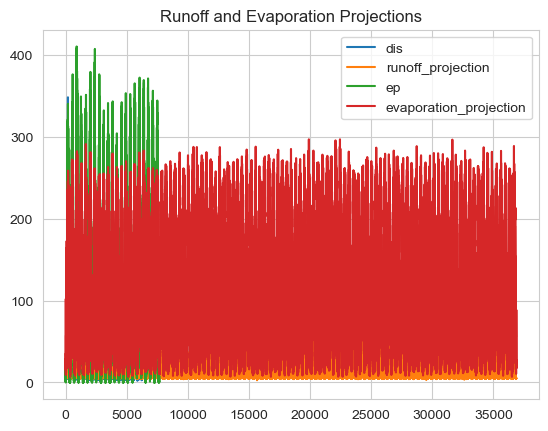

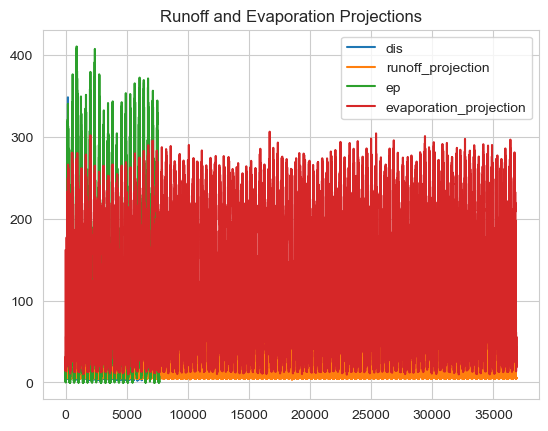

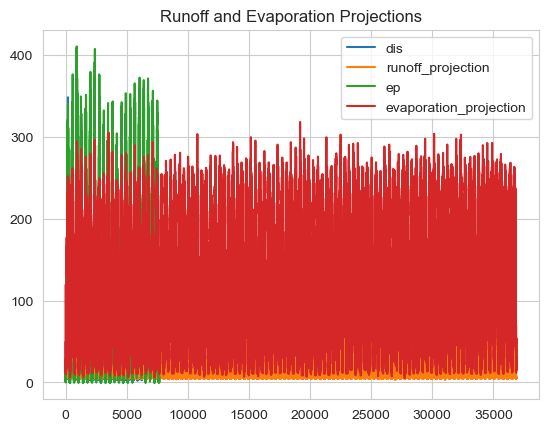

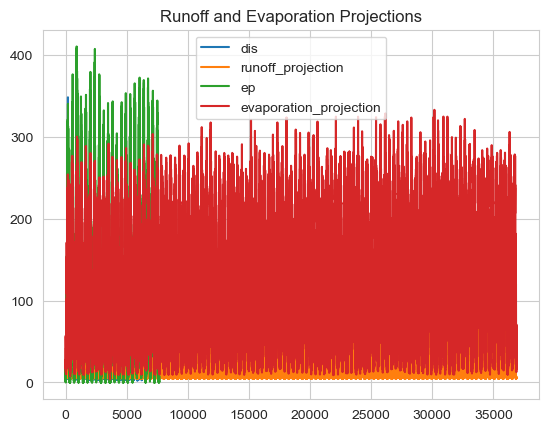

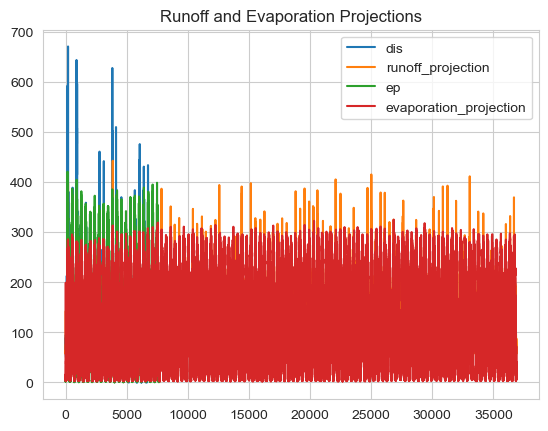

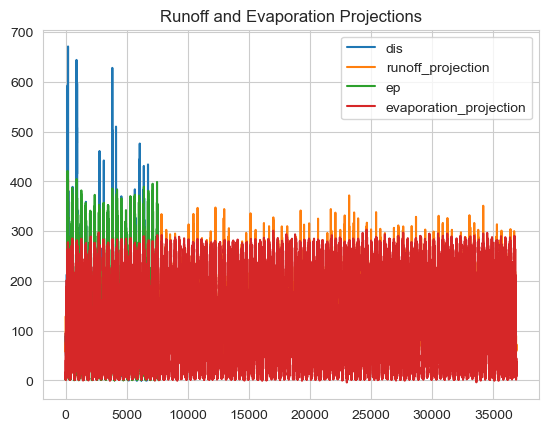

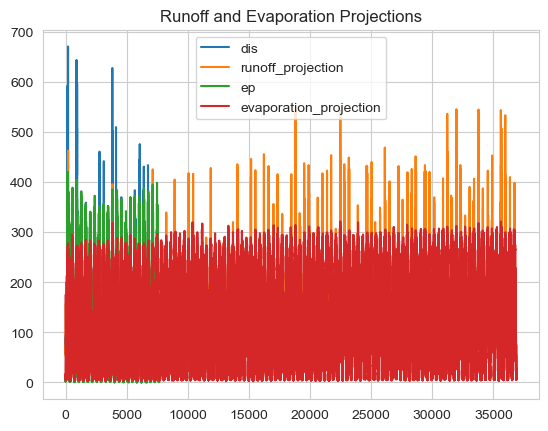

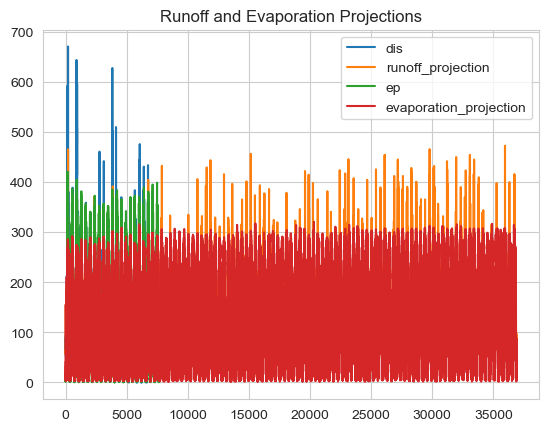

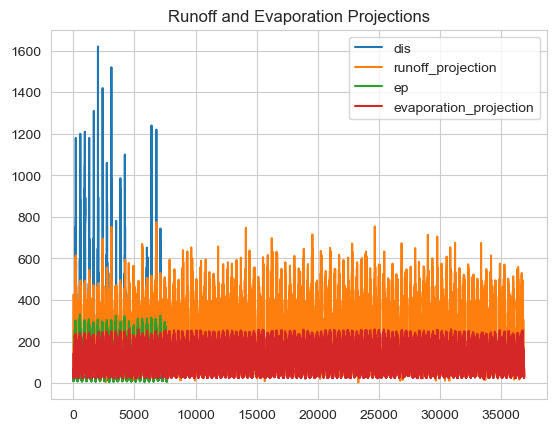

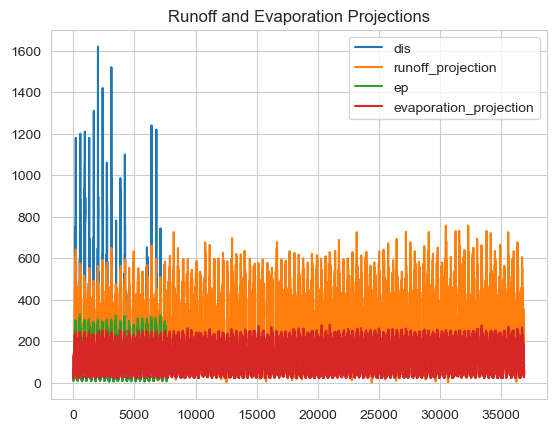

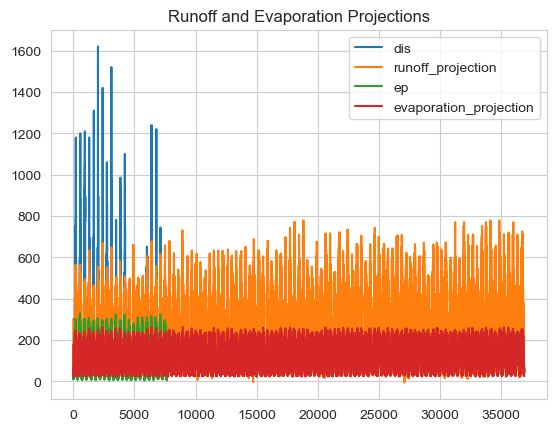

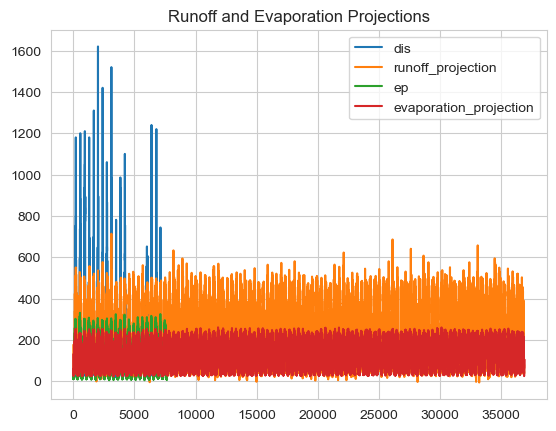

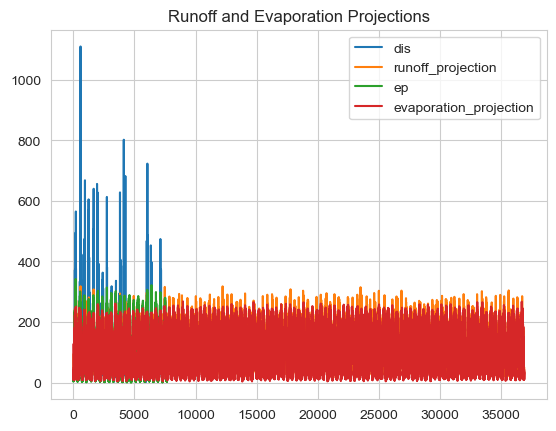

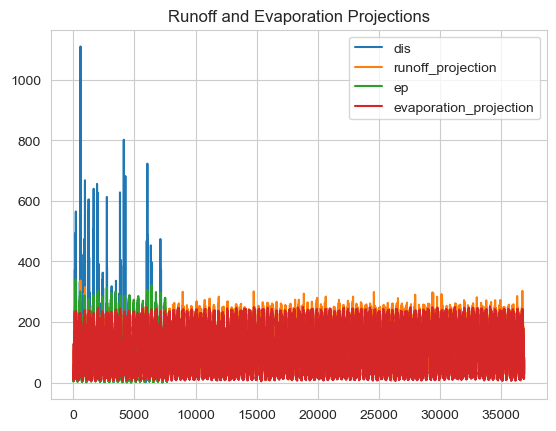

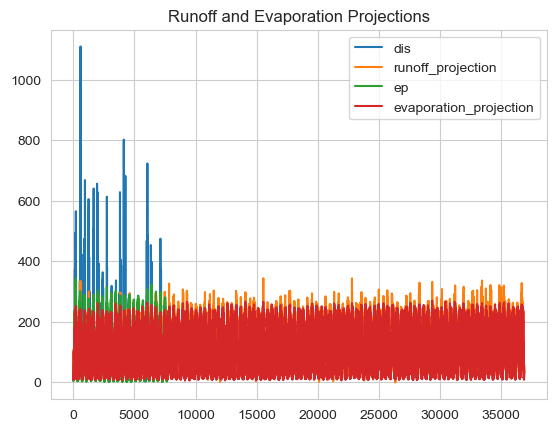

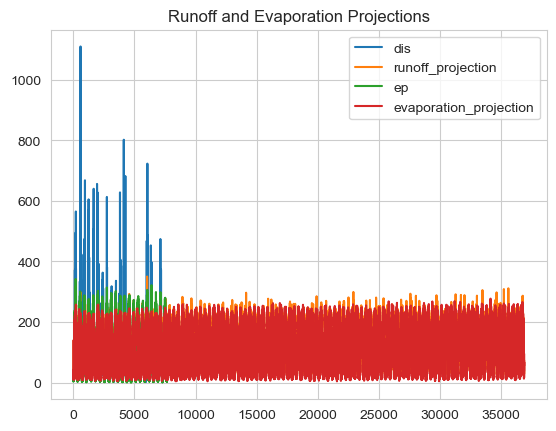

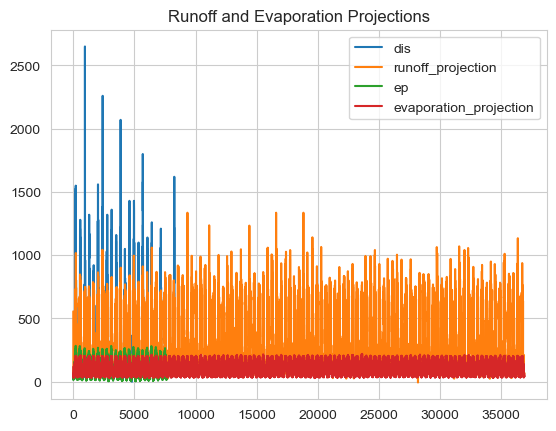

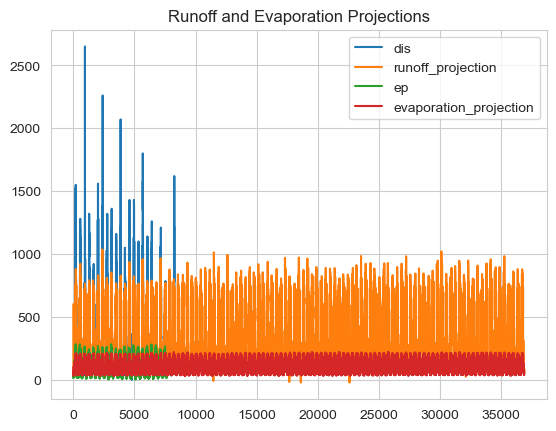

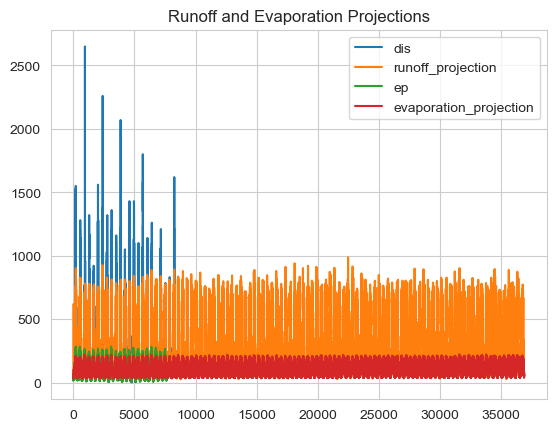

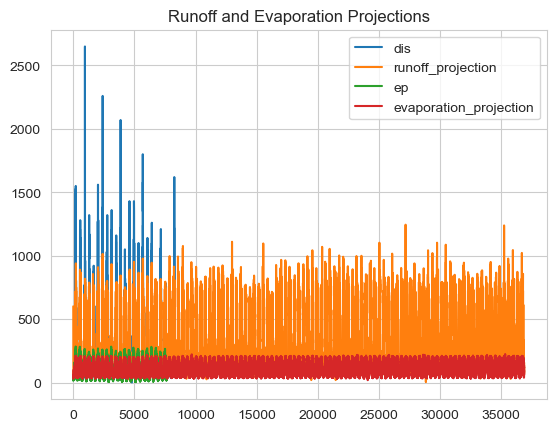

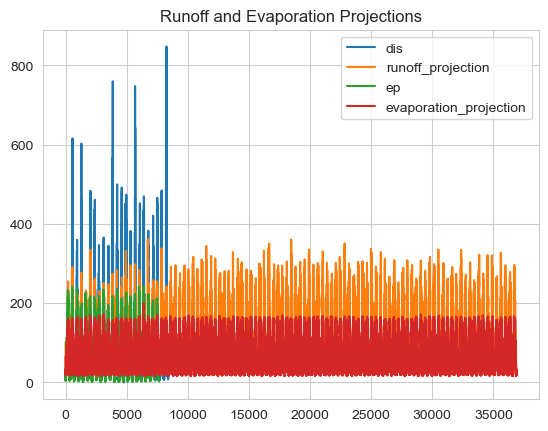

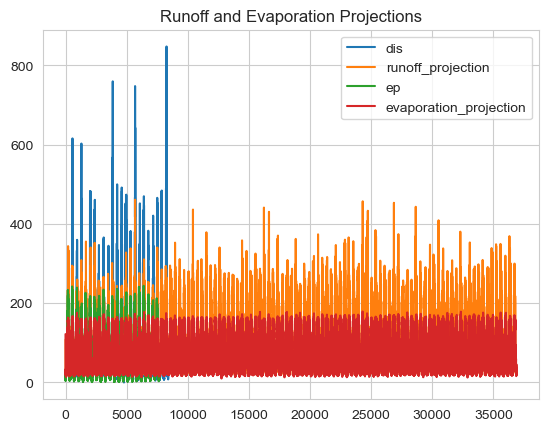

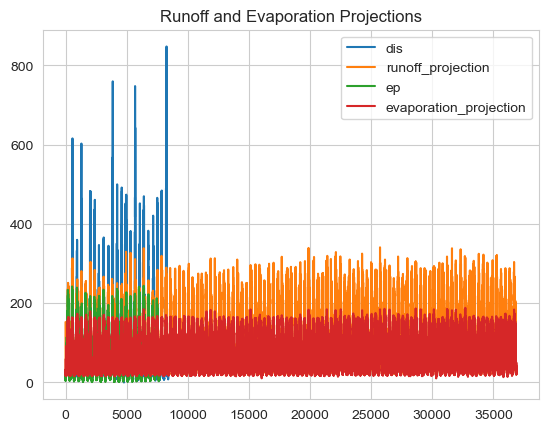

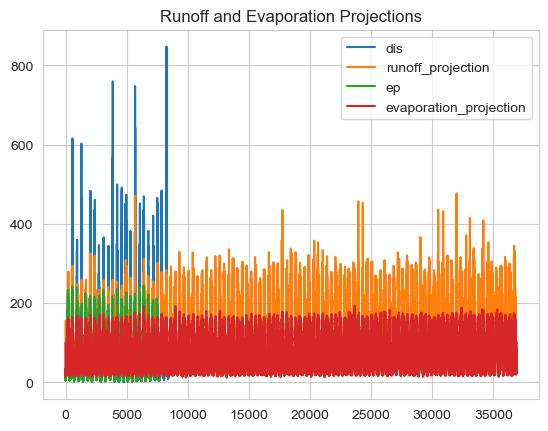

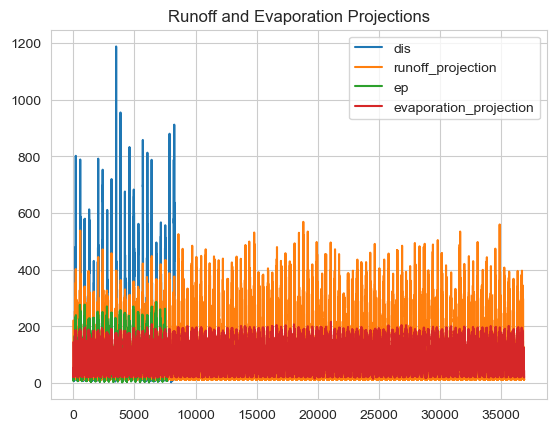

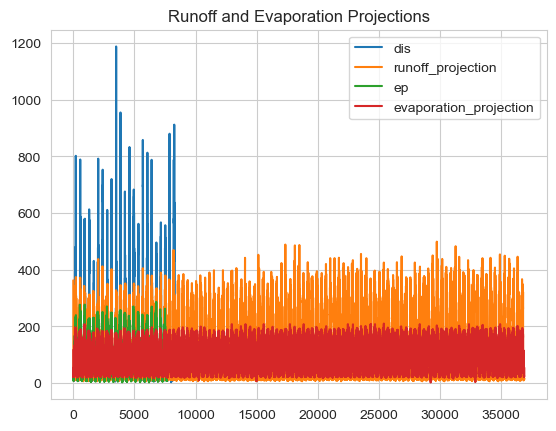

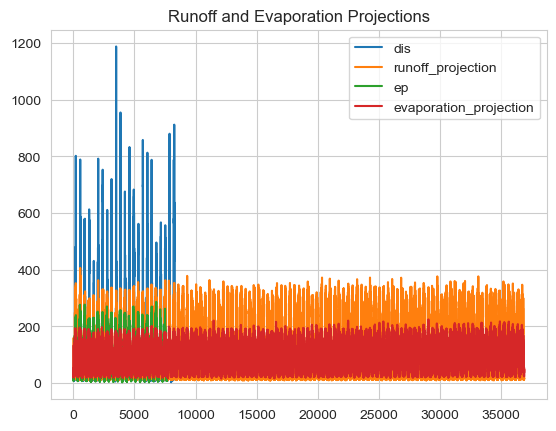

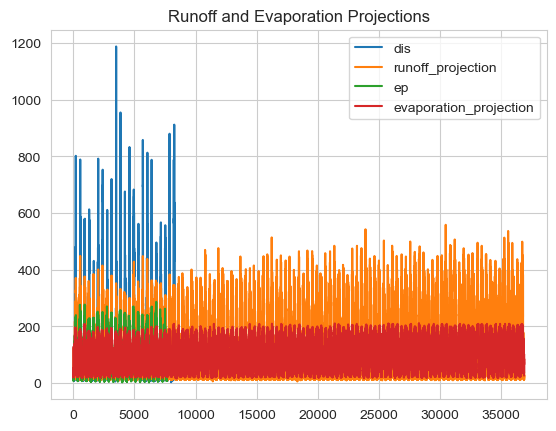

In [7]:
from datetime import datetime# Get current time
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
# 创建文件名
txtbook_path = f'F:\\geodata\\river_runoff_obs\\note\\note_XGBoost_{GCM_name}_{current_time}_daily.txt'
print(txtbook_path)

for input_file_name in input_file_name_list:
    abbre = input_file_name.split('_')[1]
    for scenario in ['ssp126','ssp245','ssp370','ssp585']:
        print(scenario)
        name = f'{input_file_name}_{GCM_name}_{scenario}_r1i1p1f1_daily'
        csv_path = f"{name}.csv"     
        data = pd.read_csv(csv_path)
        
        # Check the structure of the data
        print(data.head())
        print(data.info())
            
        # Add 1-month lag features
        data['pre_lag1'] = data['pre'].shift(1)
        data['tm_lag1'] = data['tm'].shift(1)
        
        # Drop rows with NaN values resulting from shifting
        data = data.dropna()
        
        # Select input features and target for runoff prediction
        X_runoff = data[['pre', 'tm', 'pre_lag1', 'tm_lag1']]
        y_runoff = data['dis']
        
        # Select input features and target for evaporation prediction
        y_evaporation = data['ep']
            
        
        # Split the data for both runoff and evaporation models
        X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_runoff, y_runoff, test_size=0.2, random_state=42)
        X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_runoff, y_evaporation, test_size=0.2, random_state=42)
        
        # Initialize and train the models
        model_runoff = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
        model_runoff.fit(X_train_r, y_train_r)
        model_evaporation = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
        model_evaporation.fit(X_train_e, y_train_e)
        
        # Predict and evaluate both models
        y_pred_runoff = model_runoff.predict(X_test_r)
        y_pred_evaporation = model_evaporation.predict(X_test_e)
        rmse_runoff = root_mean_squared_error(y_test_r, y_pred_runoff)
        rmse_evaporation = root_mean_squared_error(y_test_e, y_pred_evaporation)
        
        print(f"Runoff RMSE: {rmse_runoff}")
        print(f"Evaporation RMSE: {rmse_evaporation}")
        
        # Calculate NSE for runoff and evaporation
        nse_runoff = nse(y_test_r, y_pred_runoff)
        kge_runoff = kge(y_test_r, y_pred_runoff)
        pbias_runoff = pbias(y_test_r, y_pred_runoff)
        
        print('nse_runoff:',nse_runoff,'kge_runoff:',kge_runoff,'pbias_runoff:',pbias_runoff)
        nse_runoff = nse(y_test_r, y_pred_runoff)
        nse_evaporation = nse(y_test_e, y_pred_evaporation)
        print(f"Runoff NSE: {nse_runoff}")
            
        # Prepare future data inputs (remove 'dis' and 'ep' columns if they exist)
        future_data = pd.read_csv(csv_path)
        # Add 1-month lag features
        future_data['pre_lag1'] = future_data['pre'].shift(1)
        future_data['tm_lag1'] = future_data['tm'].shift(1)
        # future_data = data[data['dis'].isna() | data['ep'].isna()]
        X_future = future_data[['pre', 'tm',  'pre_lag1', 'tm_lag1']]
        
        # Predict future runoff and evaporation
        future_data['runoff_projection'] = model_runoff.predict(X_future)
        future_data['evaporation_projection'] = model_evaporation.predict(X_future)
        
        print(future_data[['time', 'runoff_projection', 'evaporation_projection']])  # Display future projections
            
        future_data.to_csv(f'XGBoost_mon\\{name}_project.csv')
        # Concatenate historical and future data
        historic_data = data.dropna(subset=['dis', 'ep'])
        combined_data = pd.concat([historic_data, future_data])
        
        # Convert the 'time' column to datetime format and set it as the index
        combined_data['time'] = pd.to_datetime(combined_data['time'], format='%Y/%m/%d', errors='coerce')
        combined_data = combined_data.dropna(subset=['time'])  # Drop any rows with invalid 'time'
        combined_data.set_index('time', inplace=True)
        
        # Display the updated DataFrame
        print(combined_data.head())
        future_data[['dis', 'runoff_projection', 'ep', 'evaporation_projection']].plot(title="Runoff and Evaporation Projections")
        
        # append the information at the end of text book
        with open(txtbook_path, 'a') as file:
            file.write(f"Name: {name}, Scenario: {scenario},NSE Runoff: {nse_runoff}, KGE Runoff: {kge_runoff},Pbias Runoff: {pbias_runoff}\n")            

In [ ]:
combined_data

In [ ]:
data 

In [ ]:
data = pd.read_csv(file_path)
# Example of adding a 1-month lag
data['pre_lag1'] = data['pre'].shift(1)
data['tm_lag1'] = data['tm'].shift(1)
data['mb_lag1'] = data['gr'].shift(1)
future_data = data[data['dis'].isna()] 
# Prepare future data inputs for the model (remove 'dis' column if it exists)
X_future = future_data[['pre', 'tm', 'gr', 'pre_lag1', 'tm_lag1', 'mb_lag1']]
future_data

In [ ]:
X_future

In [ ]:
# Predict runoff for future periods
future_data['runoff_projection'] = model.predict(X_future)
print(future_data[['time', 'runoff_projection']])  # Display future projections

In [ ]:
# Concatenate historical and future data
historic_data = data.dropna()
combined_data = pd.concat([historic_data, future_data])
# Convert the 'time' column to datetime format, matching the format of your data
combined_data['time'] = pd.to_datetime(combined_data['time'], format='%Y/%m/%d', errors='coerce')

# Drop any rows where 'time' couldn't be parsed (if there are invalid dates)
combined_data = combined_data.dropna(subset=['time'])

# Set 'time' as the index
combined_data.set_index('time', inplace=True)

# Display the updated DataFrame with 'time' as the index
print(combined_data.head())


In [ ]:
combined_data[['dis','runoff_projection']].plot()

In [ ]:
annual_data = combined_data[['dis','runoff_projection']].resample('Y').sum()

In [ ]:
annual_data.plot()